# 프로젝트: 한국어 데이터로 챗봇 만들기

## 목표
한국어 Q-A 병렬 데이터를 전처리하고 SentencePiece BPE 토크나이저를 학습한 뒤, Encoder-Decoder Transformer를 직접 구현하여 한국어 챗봇을 학습·평가한다.

## 실행 환경 및 산출물
- 환경: Google Colab + PyTorch + GPU(T4 기준)
- 데이터: `songys/Chatbot_data`의 `ChatbotData.csv`
- 토크나이저: SentencePiece BPE, vocab 8,000
- 최종 모델 설정: `d_model=256`, `num_heads=8`, `num_layers=2`, `ff_dim=512`, `dropout=0.1`
- 학습 산출물은 Google Drive의 `data/`, `models/`, `outputs/` 하위에 저장한다.

> 다른 Drive 경로에서 실행하는 경우 아래 `BASE_DIR`만 수정하면 된다. 전체 노트북은 위에서 아래로 순차 실행하는 것을 기준으로 구성하였다.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

NOTEBOOK_PATH = BASE_DIR / "EX09_transformer.ipynb"
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR :", BASE_DIR)
print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher
DATA_DIR : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data
MODEL_DIR: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models
OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs


In [ ]:
# ============================================================
# 0. Environment & Reproducibility
# ============================================================

import sys
import math
import random
import re
import unicodedata
import importlib.util
import subprocess
from pathlib import Path
from urllib.request import urlretrieve

# Colab 기본 환경에 없을 경우에만 설치
required_packages = {
    "sentencepiece": "sentencepiece",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import sentencepiece as spm
from IPython.display import display

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("Python        :", sys.version.split()[0])
print("PyTorch       :", torch.__version__)
print("SentencePiece :", spm.__version__)
print("Device        :", DEVICE)

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))

print("=" * 60)


Python        : 3.12.13
PyTorch       : 2.11.0+cu128
SentencePiece : 0.2.2
Device        : cuda
GPU           : Tesla T4


## Step 1. 데이터 수집하기
---

In [ ]:
# ============================================================
# Step 1. 한국어 챗봇 데이터 다운로드
# ============================================================

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "songys/Chatbot_data/master/ChatbotData.csv"
)

DATA_PATH = DATA_DIR / "ChatbotData.csv"

if not DATA_PATH.exists():
    urlretrieve(
        DATA_URL,
        str(DATA_PATH)
    )
    print("다운로드 완료")
else:
    print("이미 파일이 존재합니다.")

print("Data path:", DATA_PATH)
print("Exists   :", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)

print("\n[Dataset]")
print("shape   :", df.shape)
print("columns :", df.columns.tolist())

display(df.head())

이미 파일이 존재합니다.
Data path: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/ChatbotData.csv
Exists   : True

[Dataset]
shape   : (11823, 3)
columns : ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [ ]:
# ============================================================
# Step 2. 데이터 품질 확인
# ============================================================

print("[Missing Values]")
print(df.isna().sum())

print("\n[Exact Q-A Duplicates]")
print(df.duplicated(subset=["Q", "A"]).sum())

print("\n[Label Distribution]")
print(
    df["label"]
    .value_counts()
    .sort_index()
)

[Missing Values]
Q        0
A        0
label    0
dtype: int64

[Exact Q-A Duplicates]
73

[Label Distribution]
label
0    5290
1    3570
2    2963
Name: count, dtype: int64


## Step 2. 데이터 전처리하기
---

영어 데이터용 전처리를 그대로 쓰지 않고,


```
가-힣      완성형 한글
ㄱ-ㅎ      ㅋㅋ, ㅎㅎ 같은 자모
ㅏ-ㅣ      ㅠㅠ, ㅜㅜ 등의 표현
A-Z/a-z   영문
0-9       숫자
?.!,~'    주요 문장부호
```

위의 것들은 보존을 하려 합니다.

In [ ]:
# ============================================================
# 한국어 전처리
# ============================================================

def preprocess_sentence(text):
    text = str(text)

    # Unicode 한글 표현 정규화
    text = unicodedata.normalize(
        "NFC",
        text
    )

    # 영문 표기 일관성
    text = text.lower()

    # 주요 구두점을 독립된 토큰처럼 분리
    text = re.sub(
        r"([?.!,~])",
        r" \1 ",
        text
    )

    # 한글 / 자모 / 영문 / 숫자 / 주요 문장부호만 유지
    text = re.sub(
        r"[^가-힣ㄱ-ㅎㅏ-ㅣa-z0-9?.!,~'\s]",
        " ",
        text
    )

    # 중복 공백 정리
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

잘 되었는지 확인해보아요

In [ ]:
# 원본 보존
clean_df = df.copy()

clean_df["Q_clean"] = (
    clean_df["Q"]
    .apply(preprocess_sentence)
)

clean_df["A_clean"] = (
    clean_df["A"]
    .apply(preprocess_sentence)
)

print("[Before → After]")

for i in range(5):
    print("=" * 70)

    print("Q before:", clean_df.loc[i, "Q"])
    print("Q after :", clean_df.loc[i, "Q_clean"])

    print("A before:", clean_df.loc[i, "A"])
    print("A after :", clean_df.loc[i, "A_clean"])

[Before → After]
Q before: 12시 땡!
Q after : 12시 땡 !
A before: 하루가 또 가네요.
A after : 하루가 또 가네요 .
Q before: 1지망 학교 떨어졌어
Q after : 1지망 학교 떨어졌어
A before: 위로해 드립니다.
A after : 위로해 드립니다 .
Q before: 3박4일 놀러가고 싶다
Q after : 3박4일 놀러가고 싶다
A before: 여행은 언제나 좋죠.
A after : 여행은 언제나 좋죠 .
Q before: 3박4일 정도 놀러가고 싶다
Q after : 3박4일 정도 놀러가고 싶다
A before: 여행은 언제나 좋죠.
A after : 여행은 언제나 좋죠 .
Q before: PPL 심하네
Q after : ppl 심하네
A before: 눈살이 찌푸려지죠.
A after : 눈살이 찌푸려지죠 .



이번 프로젝트에서는 Q와 A가 핵심이라고 생각합니다.
```
Q = Encoder가 읽을 질문
A = Decoder가 생성하도록 학습할 정답
```



In [ ]:
# ============================================================
# 정제: 같은 질문에 다른 답변이 존재할 수도 있으니 완전 동일한 Q-A 쌍만 중복으로 처리
# ============================================================

before_rows = len(clean_df)

# 결측 제거
clean_df = clean_df.dropna(
    subset=["Q", "A"]
).copy()

# 완전히 동일한 Q-A pair 제거
clean_df = clean_df.drop_duplicates(
    subset=["Q_clean", "A_clean"]
).copy()

# 전처리 후 빈 문자열 제거
clean_df = clean_df[
    (clean_df["Q_clean"].str.len() > 0)
    &
    (clean_df["A_clean"].str.len() > 0)
].reset_index(drop=True)

after_rows = len(clean_df)

print("Before :", before_rows)
print("After  :", after_rows)
print("Removed:", before_rows - after_rows)

display(
    clean_df[
        ["Q_clean", "A_clean", "label"]
    ].head()
)

Before : 11823
After  : 11750
Removed: 73


,Q_clean,A_clean,label
0,12시 땡 !,하루가 또 가네요 .,0
1,1지망 학교 떨어졌어,위로해 드립니다 .,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠 .,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠 .,0
4,ppl 심하네,눈살이 찌푸려지죠 .,0


### 추가로 필요한 개선을 수행해요!:
SentencePiece보다 먼저 Train/Validation을 나누기


```
전체 Q-A
   ↓
Train / Validation 분리
   ↓
Train 문장으로만 SentencePiece 학습
   ↓
같은 tokenizer로 Validation 변환
```

*중요*
SentencePiece가 validation 문장의 문자·subword 분포를 미리 보는 것을 피하기 위해서임


In [ ]:
# ============================================================
# Train / Validation Split
# ============================================================

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    clean_df,
    test_size=0.10,
    random_state=SEED,
    stratify=clean_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("[Split]")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)

print("\n[Train label ratio]")
print(
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\n[Validation label ratio]")
print(
    val_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

[Split]
Train: (10575, 5)
Val  : (1175, 5)

[Train label ratio]
label
0    0.450213
1    0.297683
2    0.252104
Name: proportion, dtype: float64

[Validation label ratio]
label
0    0.450213
1    0.297872
2    0.251915
Name: proportion, dtype: float64


스플릿 결과가 정상적으로 구성되었다.

Train과 Validation의 label 비율이 거의 동일하므로, 학습에 사용하지 않는 Validation 데이터도 Train과 비슷한 대화 유형 분포를 유지한다.

```text
Train
0 : 45.02%
1 : 29.77%
2 : 25.21%

Validation
0 : 45.02%
1 : 29.79%
2 : 25.19%
```

`label`은 답변 생성의 직접적인 예측 목표로 사용하지 않고, Train/Validation 분할 시 데이터 유형 비율을 유지하기 위한 stratification 용도로만 사용한다.


### 지금까지 한 작업 의의



```
ChatbotData.csv
11,823 Q-A pairs
        │
        ▼
① 데이터 품질 검사
        │
        ├─ Missing = 0
        ├─ 동일 Q-A 중복 = 73
        └─ label 분포 확인
        │
        ▼
② 한국어 전처리
        │
        ├─ Unicode 정규화
        ├─ 영문 소문자화
        ├─ 구두점 분리
        ├─ 허용 문자 외 제거
        └─ 공백 정리
        │
        ▼
③ 중복 제거
        │
11,823 → 11,750
        │
        ▼
④ Train / Validation 분리
        │
        ├─ Train 10,575
        └─ Val    1,175
        │
        ▼
⑤ SentencePiece 학습       ***← 다음 할 일!***
```



## Step 3. SentencePiece 사용하기
---

질문만으로 tokenizer를 만들면 답변에서 등장하는 표현을 충분히 못 배울 수 있음. 그래서 Train의 Q와 A를 모두 tokenizer 학습 corpus에 넣고자 함

In [ ]:
# ============================================================
# Step 3-1. SentencePiece 학습 corpus 만들기
# ============================================================

SPM_CORPUS_PATH = DATA_DIR / "chatbot_spm_train.txt"
SPM_PREFIX = MODEL_DIR / "chatbot_spm"

with open(
    SPM_CORPUS_PATH,
    "w",
    encoding="utf-8"
) as f:

    # 질문
    for text in train_df["Q_clean"]:
        f.write(text.strip() + "\n")

    # 답변
    for text in train_df["A_clean"]:
        f.write(text.strip() + "\n")


print("SentencePiece corpus:", SPM_CORPUS_PATH)
print("Exists              :", SPM_CORPUS_PATH.exists())

print(
    "Number of lines     :",
    sum(
        1
        for _ in open(
            SPM_CORPUS_PATH,
            encoding="utf-8"
        )
    )
)

SentencePiece corpus: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/chatbot_spm_train.txt
Exists              : True
Number of lines     : 21150


#### SentencePiece BPE 8K 학습

목적은 형태소 분석기 없이 서브워드 단위로 한국어 Q/A를 안정적으로 숫자화하는 것

In [ ]:
# ============================================================
# Step 3-2. SentencePiece BPE 8K 학습
# ============================================================

VOCAB_SIZE = 8000

spm.SentencePieceTrainer.train(
    input=str(SPM_CORPUS_PATH),
    model_prefix=str(SPM_PREFIX),

    model_type="bpe",
    vocab_size=VOCAB_SIZE,

    # 한국어 문자 coverage
    character_coverage=1.0,

    # Special Tokens
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,

    pad_piece="<pad>",
    unk_piece="<unk>",
    bos_piece="<s>",
    eos_piece="</s>",

    # 작은 corpus에서 vocab 크기 문제 방지
    hard_vocab_limit=False
)

print("SentencePiece training complete.")

print(
    "Model:",
    Path(str(SPM_PREFIX) + ".model")
)

print(
    "Vocab:",
    Path(str(SPM_PREFIX) + ".vocab")
)

SentencePiece training complete.
Model: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/chatbot_spm.model
Vocab: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/chatbot_spm.vocab


In [ ]:
# ============================================================
# Step 3-3. SentencePiece 로드하고 특수 토큰 세팅 확인하기
# ============================================================

SPM_MODEL_PATH = Path(
    str(SPM_PREFIX) + ".model"
)

sp = spm.SentencePieceProcessor()

sp.load(
    str(SPM_MODEL_PATH)
)

print("=" * 60)

print("Vocabulary size:", sp.get_piece_size())

print("\n[Special Tokens]")
print("PAD :", sp.pad_id(), sp.id_to_piece(sp.pad_id()))
print("UNK :", sp.unk_id(), sp.id_to_piece(sp.unk_id()))
print("BOS :", sp.bos_id(), sp.id_to_piece(sp.bos_id()))
print("EOS :", sp.eos_id(), sp.id_to_piece(sp.eos_id()))

print("=" * 60)

# ============================================================
# Step 3-3. Special Token IDs 고정
# ============================================================

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()

VOCAB_SIZE = sp.get_piece_size()

print("VOCAB_SIZE:", VOCAB_SIZE)
print("PAD_ID :", PAD_ID)
print("UNK_ID :", UNK_ID)
print("BOS_ID :", BOS_ID)
print("EOS_ID :", EOS_ID)

Vocabulary size: 8000

[Special Tokens]
PAD : 0 <pad>
UNK : 1 <unk>
BOS : 2 <s>
EOS : 3 </s>
VOCAB_SIZE: 8000
PAD_ID : 0
UNK_ID : 1
BOS_ID : 2
EOS_ID : 3


#### 실제 한국어 데이터가 어떻게 잘리는지 확인해보기

In [ ]:
# ============================================================
# Step 3-4. Tokenization 예시
# ============================================================

sample_indices = [0, 1, 2, 100]

for idx in sample_indices:

    q = train_df.loc[idx, "Q_clean"]
    a = train_df.loc[idx, "A_clean"]

    q_pieces = sp.encode(
        q,
        out_type=str
    )

    q_ids = sp.encode(
        q,
        out_type=int
    )

    a_pieces = sp.encode(
        a,
        out_type=str
    )

    a_ids = sp.encode(
        a,
        out_type=int
    )

    print("=" * 70)

    print("[Question]")
    print("Text   :", q)
    print("Pieces :", q_pieces)
    print("IDs    :", q_ids)

    print("\n[Answer]")
    print("Text   :", a)
    print("Pieces :", a_pieces)
    print("IDs    :", a_ids)

[Question]
Text   : 커플 폰케이스 사자고 해야겠다 .
Pieces : ['▁커플', '▁폰', '케', '이스', '▁사', '자고', '▁해야겠다', '▁.']
IDs    : [1678, 1646, 7333, 2960, 6, 413, 3214, 4]

[Answer]
Text   : 괜찮은거로 골라보세요 .
Pieces : ['▁괜찮은', '거', '로', '▁골라보세요', '▁.']
IDs    : [1015, 6813, 6835, 3630, 4]
[Question]
Text   : 정말 끝이라고
Pieces : ['▁정말', '▁끝이', '라고']
IDs    : [215, 1178, 157]

[Answer]
Text   : 이별을 받아들이는 것도 중요해요 .
Pieces : ['▁이별을', '▁받아들이는', '▁것도', '▁중요해요', '▁.']
IDs    : [574, 1638, 242, 859, 4]
[Question]
Text   : 자격증 따야하나
Pieces : ['▁자격증', '▁따', '야하나']
IDs    : [3548, 234, 3930]

[Answer]
Text   : 뭐든 좋죠 .
Pieces : ['▁뭐든', '▁좋죠', '▁.']
IDs    : [1596, 386, 4]
[Question]
Text   : 개같이 되버렸어 .
Pieces : ['▁개', '같이', '▁되', '버렸어', '▁.']
IDs    : [620, 2463, 78, 2201, 4]

[Answer]
Text   : 벗어나는 게 좋겠네요 .
Pieces : ['▁벗어나', '는', '▁게', '▁좋겠네요', '▁.']
IDs    : [2093, 6799, 90, 584, 4]


지금은 subword ID만 나오는데, 이제 인코더 디코더 챗봇에서는 문장 시작, 문장 끝 토큰의 배열이 필요함.

In [ ]:
# ============================================================
# Step 3-5. BOS / EOS 포함 인코딩
# ============================================================

def encode_sentence(text):
    ids = sp.encode(
        text,
        out_type=int
    )

    return [
        BOS_ID,
        *ids,
        EOS_ID
    ]

In [ ]:
sample_text = train_df.loc[0, "Q_clean"]

sample_ids = encode_sentence(
    sample_text
)

print("Text   :", sample_text)
print("IDs    :", sample_ids)

print(
    "Pieces :",
    [
        sp.id_to_piece(i)
        for i in sample_ids
    ]
)

print(
    "Decoded:",
    sp.decode(
        [
            i
            for i in sample_ids
            if i not in {
                BOS_ID,
                EOS_ID,
                PAD_ID
            }
        ]
    )
)

Text   : 커플 폰케이스 사자고 해야겠다 .
IDs    : [2, 1678, 1646, 7333, 2960, 6, 413, 3214, 4, 3]
Pieces : ['<s>', '▁커플', '▁폰', '케', '이스', '▁사', '자고', '▁해야겠다', '▁.', '</s>']
Decoded: 커플 폰케이스 사자고 해야겠다 .


In [ ]:
# ============================================================
# Step 3-6. Token Length 분석
# ============================================================

train_q_lengths = (
    train_df["Q_clean"]
    .apply(lambda x: len(encode_sentence(x)))
    .to_numpy()
)

train_a_lengths = (
    train_df["A_clean"]
    .apply(lambda x: len(encode_sentence(x)))
    .to_numpy()
)

all_lengths = np.concatenate(
    [
        train_q_lengths,
        train_a_lengths
    ]
)

print("[Token Length Statistics]")
print("Count :", len(all_lengths))
print("Mean  :", all_lengths.mean())
print("Median:", np.median(all_lengths))
print("90%   :", np.percentile(all_lengths, 90))
print("95%   :", np.percentile(all_lengths, 95))
print("99%   :", np.percentile(all_lengths, 99))
print("Max   :", all_lengths.max())

print("\n[MAX_LEN Coverage]")

for max_len in [20, 30, 40, 50, 60]:
    coverage = (
        all_lengths <= max_len
    ).mean() * 100

    print(
        f"MAX_LEN={max_len:2d}"
        f" → coverage={coverage:.2f}%"
    )

[Token Length Statistics]
Count : 21150
Mean  : 7.5916312056737585
Median: 7.0
90%   : 11.0
95%   : 12.0
99%   : 15.0
Max   : 31

[MAX_LEN Coverage]
MAX_LEN=20 → coverage=99.87%
MAX_LEN=30 → coverage=100.00%
MAX_LEN=40 → coverage=100.00%
MAX_LEN=50 → coverage=100.00%
MAX_LEN=60 → coverage=100.00%


Max 길이 설정에 대한 고찰:


```
MAX_LEN=20
→ 매우 효율적
→ 하지만 약 0.13% 문장 손실/절단

MAX_LEN=32
→ 전체 Train 문장 보존
→ 계산량도 적당
→ !!확정!!

MAX_LEN=40
→ 전체 보존
→ 하지만 32보다 특별한 이점 없이 Padding 증가
```



In [ ]:
# ============================================================
# Step 3-7. MAX_LEN 적용
# ============================================================

MAX_LEN = 32

print("MAX_LEN:", MAX_LEN)
print("PAD_ID :", PAD_ID)
print("BOS_ID :", BOS_ID)
print("EOS_ID :", EOS_ID)

MAX_LEN: 32
PAD_ID : 0
BOS_ID : 2
EOS_ID : 3


In [ ]:
#이제 모든 문장을 정확히 32 길이로 만들기!

def encode_and_pad(text, max_len=MAX_LEN):
    # 1. SentencePiece
    token_ids = sp.encode(
        text,
        out_type=int
    )

    # 2. BOS / EOS
    ids = [
        BOS_ID,
        *token_ids,
        EOS_ID
    ]

    # 3. 혹시 MAX_LEN보다 긴 문장이 있으면 truncate
    #    마지막에는 반드시 EOS를 남김
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = EOS_ID

    # 4. 부족한 부분은 PAD
    else:
        ids += [PAD_ID] * (
            max_len - len(ids)
        )

    return ids

In [ ]:
# 샘플 확인해보기
sample_q = train_df.loc[0, "Q_clean"]
sample_a = train_df.loc[0, "A_clean"]

q_ids = encode_and_pad(sample_q)
a_ids = encode_and_pad(sample_a)

print("[Question]")
print("Text :", sample_q)
print("IDs  :", q_ids)
print("Length:", len(q_ids))

print("\n[Answer]")
print("Text :", sample_a)
print("IDs  :", a_ids)
print("Length:", len(a_ids))

[Question]
Text : 커플 폰케이스 사자고 해야겠다 .
IDs  : [2, 1678, 1646, 7333, 2960, 6, 413, 3214, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32

[Answer]
Text : 괜찮은거로 골라보세요 .
IDs  : [2, 1015, 6813, 6835, 3630, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32


#### 이제 판다스DF를 파이토치 Dataset으로 변형~

In [ ]:
from torch.utils.data import Dataset, DataLoader


class ChatbotDataset(Dataset):
    def __init__(self, dataframe):
        self.questions = (
            dataframe["Q_clean"]
            .tolist()
        )

        self.answers = (
            dataframe["A_clean"]
            .tolist()
        )

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        src_ids = encode_and_pad(
            self.questions[idx]
        )

        tgt_ids = encode_and_pad(
            self.answers[idx]
        )

        return (
            torch.tensor(
                src_ids,
                dtype=torch.long
            ),
            torch.tensor(
                tgt_ids,
                dtype=torch.long
            )
        )

In [ ]:
train_dataset = ChatbotDataset(
    train_df
)

val_dataset = ChatbotDataset(
    val_df
)

print("Train Dataset:", len(train_dataset))
print("Val Dataset  :", len(val_dataset))

Train Dataset: 10575
Val Dataset  : 1175


In [ ]:
# 현재 T4 돌리고 있고 Max_Len 32. 배치 사이즈는 일단 64로 설정해보겠음
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches  :",
    len(val_loader)
)

Train batches: 166
Val batches  : 19


#### Teacher Forcing을 시작해봅니다...

In [ ]:
src_batch, tgt_full_batch = next(
    iter(train_loader)
)

print("[Before Teacher Forcing]")
print(
    "Source batch     :",
    src_batch.shape
)

print(
    "Full target batch:",
    tgt_full_batch.shape
)

[Before Teacher Forcing]
Source batch     : torch.Size([64, 32])
Full target batch: torch.Size([64, 32])


In [ ]:
# 답변을 한칸씩 시프트 시키는 순간입니다!
# ============================================================
# Teacher Forcing
# ============================================================

tgt_input = (
    tgt_full_batch[:, :-1]
)

labels = (
    tgt_full_batch[:, 1:]
)

print("[After Teacher Forcing]")
print(
    "Decoder input:",
    tgt_input.shape
)

print(
    "Labels       :",
    labels.shape
)

[After Teacher Forcing]
Decoder input: torch.Size([64, 31])
Labels       : torch.Size([64, 31])


In [ ]:
# 직접 보고 시프트를 한번 확인해봅시다.
sample_idx = 0

full_ids = tgt_full_batch[
    sample_idx
].tolist()

input_ids = tgt_input[
    sample_idx
].tolist()

label_ids = labels[
    sample_idx
].tolist()


def ids_to_pieces(ids):
    return [
        sp.id_to_piece(i)
        for i in ids
    ]


print("=" * 70)

print("[Full Target]")
print(ids_to_pieces(full_ids))

print("\n[Decoder Input]")
print(ids_to_pieces(input_ids))

print("\n[Labels]")
print(ids_to_pieces(label_ids))

print("=" * 70)

[Full Target]
['<s>', '▁절대', '▁능력', '만', '▁중요하지', '▁않아요', '▁.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

[Decoder Input]
['<s>', '▁절대', '▁능력', '만', '▁중요하지', '▁않아요', '▁.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

[Labels]
['▁절대', '▁능력', '만', '▁중요하지', '▁않아요', '▁.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


### Teacher Forcing 시프트 확인

답변 전체를 한 칸씩 어긋나게 만들어 Decoder 입력과 다음-token 정답을 구성했다.

```text
Decoder가 받은 것          맞혀야 하는 것

<s>                  →     첫 답변 토큰
첫 답변 토큰          →     다음 답변 토큰
...
마지막 답변 토큰       →     </s>
```

따라서 학습 중 Decoder는 이전의 정답 토큰을 입력으로 받되, Causal Mask 때문에 미래의 정답 토큰은 볼 수 없다.


### Padding은 Loss에서 또 처리하는 구성입니다.

학습단계에서는 그래서


```
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)
```
이런 구간이 있는데, Label이 <pad>인 위치는 loss 계산에서 제외함.

역할을 한 번 더 정리하자면 -


```
Padding Mask
→ Attention이 PAD 정보를 참고하지 않게 함

ignore_index=PAD_ID
→ PAD 예측을 Loss에 반영하지 않음
```




### 다시 한 번 정리
미래의 정답까지 한꺼번에 텐서 안에 들어있어도 디코더의 캐주얼 마스크 때문에 미래 위치는 볼 수 없는 상태인 것을 이해했습니다.


```
Teacher Forcing
→ 과거의 정답 토큰을 제공

Causal Mask
→ 미래의 정답 토큰은 차단

ignore_index=PAD_ID
→ PAD를 맞히는 문제는 Loss에서 제외
```



## Step 4. 모델 구성하기
---

이전에 구조 실습때 썼던 작은 모델과 비교해보면 조금 확대되었습니다:



```
연습
d_model=8
heads=2
layer=2

       ↓

EX09 실제 모델
d_model=256
heads=8
layer=2
```



In [ ]:
# ============================================================
# Step 4-1. Transformer Hyperparameters
# ============================================================

VOCAB_SIZE = sp.get_piece_size()   # 8000
MAX_LEN = 32

D_MODEL = 256
NUM_HEADS = 8
NUM_LAYERS = 2
FF_DIM = 512
DROPOUT = 0.1

print("[Transformer Configuration]")
print("VOCAB_SIZE :", VOCAB_SIZE)
print("MAX_LEN    :", MAX_LEN)
print("D_MODEL    :", D_MODEL)
print("NUM_HEADS  :", NUM_HEADS)
print("HEAD_DIM   :", D_MODEL // NUM_HEADS)
print("NUM_LAYERS :", NUM_LAYERS)
print("FF_DIM     :", FF_DIM)
print("DROPOUT    :", DROPOUT)

[Transformer Configuration]
VOCAB_SIZE : 8000
MAX_LEN    : 32
D_MODEL    : 256
NUM_HEADS  : 8
HEAD_DIM   : 32
NUM_LAYERS : 2
FF_DIM     : 512
DROPOUT    : 0.1


#### 256/8 = 32
Multi-Head 분할 조건을 충족시키기 위한 것도 있어요.

원조 트랜스포머처럼 6층, 512차원으로 하지 않은 이유는 현재 데이터 정제 후 페어가 약 1.2만개여서 이에 대한 과적합 예방을 위한 적정 규모를 찾아본 결론입니다.

In [ ]:
# ============================================================
# Step 4-1-2. Transformer Model Components
# ============================================================

import math

import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# 1. Positional Encoding
# ------------------------------------------------------------

class PositionalEncoding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()

        position = torch.arange(
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        dimension = torch.arange(
            d_model,
            dtype=torch.float32
        ).unsqueeze(0)

        angle_rates = 1.0 / (
            10000.0 **
            (
                2.0 *
                (dimension // 2) /
                d_model
            )
        )

        angle_rads = position * angle_rates

        pe = torch.zeros(
            max_len,
            d_model,
            dtype=torch.float32
        )

        pe[:, 0::2] = torch.sin(
            angle_rads[:, 0::2]
        )

        pe[:, 1::2] = torch.cos(
            angle_rads[:, 1::2]
        )

        # [1, max_len, d_model]
        pe = pe.unsqueeze(0)

        self.register_buffer(
            "pos_encoding",
            pe
        )

    def forward(self, x):
        seq_len = x.size(1)

        return (
            x +
            self.pos_encoding[
                :, :seq_len, :
            ]
        )


# ------------------------------------------------------------
# 2. Scaled Dot-Product Attention
# ------------------------------------------------------------

def scaled_dot_product_attention(
    query,
    key,
    value,
    additive_mask=None
):
    # [B,H,Q,D] @ [B,H,D,K]
    # -> [B,H,Q,K]
    scores = torch.matmul(
        query,
        key.transpose(-1, -2)
    )

    d_k = query.size(-1)

    scores = (
        scores /
        math.sqrt(d_k)
    )

    if additive_mask is not None:
        scores = (
            scores +
            additive_mask
        )

    attention_weights = F.softmax(
        scores,
        dim=-1
    )

    output = torch.matmul(
        attention_weights,
        value
    )

    return output, attention_weights


# ------------------------------------------------------------
# 3. Multi-Head Attention
# ------------------------------------------------------------

class MultiHeadAttentionManual(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int
    ):
        super().__init__()

        assert (
            d_model % num_heads == 0
        ), "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = (
            d_model // num_heads
        )

        self.query_dense = nn.Linear(
            d_model,
            d_model
        )

        self.key_dense = nn.Linear(
            d_model,
            d_model
        )

        self.value_dense = nn.Linear(
            d_model,
            d_model
        )

        self.out_dense = nn.Linear(
            d_model,
            d_model
        )

    def split_heads(self, x):
        batch_size, seq_len, _ = x.shape

        # [B,S,D]
        # -> [B,S,H,depth]
        x = x.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.depth
        )

        # -> [B,H,S,depth]
        return x.permute(
            0, 2, 1, 3
        )

    def forward(
        self,
        query,
        key,
        value,
        additive_mask=None
    ):
        batch_size = query.size(0)

        # Q, K, V projection
        q = self.query_dense(query)
        k = self.key_dense(key)
        v = self.value_dense(value)

        # head 분리
        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        attention_output, attention_weights = (
            scaled_dot_product_attention(
                q,
                k,
                v,
                additive_mask=additive_mask
            )
        )

        # [B,H,S,depth]
        # -> [B,S,H,depth]
        attention_output = (
            attention_output
            .permute(0, 2, 1, 3)
            .contiguous()
        )

        # -> [B,S,D]
        attention_output = (
            attention_output.view(
                batch_size,
                -1,
                self.d_model
            )
        )

        output = self.out_dense(
            attention_output
        )

        return output, attention_weights


# ------------------------------------------------------------
# 4. Encoder Layer
# ------------------------------------------------------------

class EncoderLayerManual(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        ff_dim: int,
        dropout: float = 0.1
    ):
        super().__init__()

        self.mha = MultiHeadAttentionManual(
            d_model,
            num_heads
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                d_model,
                ff_dim
            ),
            nn.ReLU(),
            nn.Linear(
                ff_dim,
                d_model
            )
        )

        self.dropout1 = nn.Dropout(
            dropout
        )

        self.dropout2 = nn.Dropout(
            dropout
        )

        self.norm1 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.norm2 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

    def forward(
        self,
        x,
        additive_mask=None
    ):
        # Encoder Self-Attention
        # Q = K = V = x
        attn_output, attn_weights = (
            self.mha(
                x,
                x,
                x,
                additive_mask
            )
        )

        attn_output = self.dropout1(
            attn_output
        )

        # Residual + LayerNorm
        out1 = self.norm1(
            x + attn_output
        )

        # FFN
        ffn_output = self.ffn(
            out1
        )

        ffn_output = self.dropout2(
            ffn_output
        )

        # Residual + LayerNorm
        out2 = self.norm2(
            out1 + ffn_output
        )

        return out2, attn_weights


# ------------------------------------------------------------
# 5. Encoder
# ------------------------------------------------------------

class EncoderManual(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        num_layers: int,
        ff_dim: int,
        d_model: int,
        num_heads: int,
        pad_id: int,
        dropout: float = 0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.pos_encoding = PositionalEncoding(
            max_len,
            d_model
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.layers = nn.ModuleList([
            EncoderLayerManual(
                d_model=d_model,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

    def forward(
        self,
        token_ids,
        additive_mask=None
    ):
        # [B,S] -> [B,S,D]
        x = self.embedding(
            token_ids
        )

        x = (
            x *
            math.sqrt(self.d_model)
        )

        x = self.pos_encoding(
            x
        )

        x = self.dropout(
            x
        )

        attention_maps = []

        for layer in self.layers:
            x, attn = layer(
                x,
                additive_mask
            )

            attention_maps.append(
                attn
            )

        return x, attention_maps


# ------------------------------------------------------------
# 6. Decoder Layer
# ------------------------------------------------------------

class DecoderLayerManual(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        ff_dim: int,
        dropout: float = 0.1
    ):
        super().__init__()

        # Decoder Masked Self-Attention
        self.self_mha = (
            MultiHeadAttentionManual(
                d_model,
                num_heads
            )
        )

        # Encoder-Decoder Cross-Attention
        self.cross_mha = (
            MultiHeadAttentionManual(
                d_model,
                num_heads
            )
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                d_model,
                ff_dim
            ),
            nn.ReLU(),
            nn.Linear(
                ff_dim,
                d_model
            )
        )

        self.dropout1 = nn.Dropout(
            dropout
        )

        self.dropout2 = nn.Dropout(
            dropout
        )

        self.dropout3 = nn.Dropout(
            dropout
        )

        self.norm1 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.norm2 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.norm3 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

    def forward(
        self,
        x,
        enc_outputs,
        self_mask=None,
        cross_mask=None
    ):
        # 1. Masked Self-Attention
        self_attn, self_weights = (
            self.self_mha(
                x,
                x,
                x,
                self_mask
            )
        )

        self_attn = self.dropout1(
            self_attn
        )

        out1 = self.norm1(
            x + self_attn
        )

        # 2. Cross-Attention
        # Q = Decoder
        # K,V = Encoder
        cross_attn, cross_weights = (
            self.cross_mha(
                out1,
                enc_outputs,
                enc_outputs,
                cross_mask
            )
        )

        cross_attn = self.dropout2(
            cross_attn
        )

        out2 = self.norm2(
            out1 + cross_attn
        )

        # 3. FFN
        ffn_output = self.ffn(
            out2
        )

        ffn_output = self.dropout3(
            ffn_output
        )

        out3 = self.norm3(
            out2 + ffn_output
        )

        return (
            out3,
            self_weights,
            cross_weights
        )


# ------------------------------------------------------------
# 7. Decoder
# ------------------------------------------------------------

class DecoderManual(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        num_layers: int,
        ff_dim: int,
        d_model: int,
        num_heads: int,
        pad_id: int,
        dropout: float = 0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.pos_encoding = PositionalEncoding(
            max_len,
            d_model
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.layers = nn.ModuleList([
            DecoderLayerManual(
                d_model=d_model,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

    def forward(
        self,
        token_ids,
        enc_outputs,
        self_mask=None,
        cross_mask=None
    ):
        x = self.embedding(
            token_ids
        )

        x = (
            x *
            math.sqrt(self.d_model)
        )

        x = self.pos_encoding(
            x
        )

        x = self.dropout(
            x
        )

        layer_traces = []

        for layer in self.layers:
            (
                x,
                self_attn,
                cross_attn
            ) = layer(
                x,
                enc_outputs,
                self_mask,
                cross_mask
            )

            layer_traces.append({
                "self_attention":
                    self_attn,

                "cross_attention":
                    cross_attn
            })

        return x, layer_traces


# ------------------------------------------------------------
# 8. Attention Masks
# ------------------------------------------------------------

def make_padding_additive_mask(
    token_ids,
    pad_id
):
    # [B,S]
    # -> [B,1,1,S]

    mask = torch.zeros(
        token_ids.size(0),
        1,
        1,
        token_ids.size(1),
        device=token_ids.device
    )

    mask = mask.masked_fill(
        token_ids.eq(pad_id)[
            :, None, None, :
        ],
        float("-inf")
    )

    return mask


def make_causal_additive_mask(
    seq_len,
    device
):
    # [1,1,T,T]

    mask = torch.triu(
        torch.full(
            (seq_len, seq_len),
            float("-inf"),
            device=device
        ),
        diagonal=1
    )

    return mask[
        None,
        None,
        :,
        :
    ]


def make_decoder_self_mask(
    token_ids,
    pad_id
):
    causal_mask = (
        make_causal_additive_mask(
            token_ids.size(1),
            token_ids.device
        )
    )

    padding_mask = (
        make_padding_additive_mask(
            token_ids,
            pad_id
        )
    )

    return (
        causal_mask +
        padding_mask
    )


# ------------------------------------------------------------
# 9. Full Transformer
# ------------------------------------------------------------

class TransformerManual(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        num_layers: int,
        ff_dim: int,
        d_model: int,
        num_heads: int,
        pad_id: int,
        dropout: float = 0.1
    ):
        super().__init__()

        self.pad_id = pad_id

        self.encoder = EncoderManual(
            vocab_size=vocab_size,
            max_len=max_len,
            num_layers=num_layers,
            ff_dim=ff_dim,
            d_model=d_model,
            num_heads=num_heads,
            pad_id=pad_id,
            dropout=dropout
        )

        self.decoder = DecoderManual(
            vocab_size=vocab_size,
            max_len=max_len,
            num_layers=num_layers,
            ff_dim=ff_dim,
            d_model=d_model,
            num_heads=num_heads,
            pad_id=pad_id,
            dropout=dropout
        )

        # Decoder hidden state
        # -> Vocabulary logits
        self.final_linear = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(
        self,
        src_ids,
        tgt_input_ids
    ):
        # Encoder에서 PAD 차단
        src_padding_mask = (
            make_padding_additive_mask(
                src_ids,
                self.pad_id
            )
        )

        # Decoder:
        # 미래 + target PAD 차단
        tgt_self_mask = (
            make_decoder_self_mask(
                tgt_input_ids,
                self.pad_id
            )
        )

        enc_outputs, enc_attentions = (
            self.encoder(
                src_ids,
                src_padding_mask
            )
        )

        dec_outputs, dec_traces = (
            self.decoder(
                tgt_input_ids,
                enc_outputs,

                self_mask=
                    tgt_self_mask,

                # Cross-Attention에서는
                # Encoder의 PAD 위치를 차단
                cross_mask=
                    src_padding_mask
            )
        )

        logits = self.final_linear(
            dec_outputs
        )

        trace = {
            "encoder_output":
                enc_outputs,

            "decoder_output":
                dec_outputs,

            "encoder_attentions":
                enc_attentions,

            "decoder_layers":
                dec_traces,

            "src_padding_mask":
                src_padding_mask,

            "tgt_self_mask":
                tgt_self_mask
        }

        return logits, trace


print("Transformer components defined successfully.")

Transformer components defined successfully.


In [ ]:
# ============================================================
# Step 4-2. Build Transformer
# ============================================================

model = TransformerManual(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    pad_id=PAD_ID,
    dropout=DROPOUT
).to(DEVICE)

print("Model device:", next(model.parameters()).device)

num_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters    : {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model device: cuda:0
Total parameters    : 8,787,776
Trainable parameters: 8,787,776


In [ ]:
# 한국어 배치 하나 꺼내서 트랜스포머 태워보기

# ============================================================
# Step 4-3. Real Korean Batch Forward Pass
# ============================================================

src_batch, tgt_full_batch = next(
    iter(train_loader)
)

# GPU로 이동
src_batch = src_batch.to(DEVICE)
tgt_full_batch = tgt_full_batch.to(DEVICE)

# Teacher Forcing
tgt_input = tgt_full_batch[:, :-1]
labels = tgt_full_batch[:, 1:]

model.eval()

with torch.no_grad():

    logits, trace = model(
        src_batch,
        tgt_input
    )


print("=" * 70)

print("[Actual Korean Batch]")

print(
    "Source             :",
    src_batch.shape
)

print(
    "Decoder input      :",
    tgt_input.shape
)

print(
    "Labels             :",
    labels.shape
)

print("\n[Transformer]")

print(
    "Encoder output     :",
    trace["encoder_output"].shape
)

print(
    "Decoder output     :",
    trace["decoder_output"].shape
)

print(
    "Vocabulary logits  :",
    logits.shape
)

print("\n[Last Decoder Layer]")

print(
    "Self Attention     :",
    trace["decoder_layers"][-1]
         ["self_attention"].shape
)

print(
    "Cross Attention    :",
    trace["decoder_layers"][-1]
         ["cross_attention"].shape
)

print("=" * 70)

[Actual Korean Batch]
Source             : torch.Size([64, 32])
Decoder input      : torch.Size([64, 31])
Labels             : torch.Size([64, 31])

[Transformer]
Encoder output     : torch.Size([64, 32, 256])
Decoder output     : torch.Size([64, 31, 256])
Vocabulary logits  : torch.Size([64, 31, 8000])

[Last Decoder Layer]
Self Attention     : torch.Size([64, 8, 31, 31])
Cross Attention    : torch.Size([64, 8, 31, 32])


#### 한국어 정답으로 loss 계산해보기

In [ ]:
# ============================================================
# Step 4-4. Real Korean Loss Sanity Check
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

loss = criterion(
    logits.reshape(
        -1,
        VOCAB_SIZE
    ),
    labels.reshape(-1)
)

print("Logits shape :", logits.shape)
print("Labels shape :", labels.shape)

print(
    "Initial Loss :",
    loss.item()
)

print(
    "Loss finite  :",
    torch.isfinite(loss).item()
)

Logits shape : torch.Size([64, 31, 8000])
Labels shape : torch.Size([64, 31])
Initial Loss : 9.100671768188477
Loss finite  : True


`ignore_index=PAD_ID`

가 있기 때문에 이 중 정답이 <pad>인 문제는 Loss에서 제외됨!

#### 현재까지 진행한 것을 정리해보면:



```
한국어 질문/답변
→ SentencePiece
→ Token IDs
→ Padding
→ Teacher Forcing
→ Encoder
→ Decoder
→ 8,000개 단어 후보 점수
→ 실제 정답과 비교하여 Loss 계산
```

### 그 중 특히 인상 깊은 부분:

```
Self-Attention [64, 8, 31, 31]
Self Attention : [64, 8, 31, 31]
```
해석해보면:

- 64 = batch
- 8 = attention head
- 31 = Query 위치
- 31 = Key 위치

즉 Decoder의 답변 31개 위치가 서로 어떤 관계가 있는지 8개의 서로 다른 Attention 관점에서 계산한다는 의미로 이해했습니다.



```
Cross Attention : [64, 8, 31, 32]
```

답변의 각 위치가 질문의 32개 위치 중 어디를 참고할 지 계산한 형태
```
64 = batch
8  = heads
*31* = Decoder Query
*32* = Encoder Key
```





### 현황:

- Forward      `성공`
- Attention    `성공`
- Logits       `성공`
- Loss         `9.1007`
- finite       `True`

PyTorch의 autograd는 Forward 과정의 연산 그래프를 기록하고 backward() 때 chain rule을 따라 각 학습 파라미터의 gradient를 계산한다.

그리고 아까의 loss는 torch.no_grad() 안에서 계산했으므로 그 값을 그대로 backward하면 안 된다고 함.(정확히 다 이해하지는 못함)
학습 그래프를 만들기 위해 Forward를 새로 한 번 수행해야합니다!

In [ ]:
# ============================================================
# Step 4-5. Backward Sanity Check
# ============================================================

model.train()

# 새로운 실제 batch 하나
probe_src, probe_tgt_full = next(
    iter(train_loader)
)

probe_src = probe_src.to(DEVICE)
probe_tgt_full = probe_tgt_full.to(DEVICE)

probe_tgt_input = probe_tgt_full[:, :-1]
probe_labels = probe_tgt_full[:, 1:]


# 이전 gradient가 있다면 제거
model.zero_grad(set_to_none=True)


# Forward
probe_logits, _ = model(
    probe_src,
    probe_tgt_input
)

probe_loss = criterion(
    probe_logits.reshape(
        -1,
        VOCAB_SIZE
    ),
    probe_labels.reshape(-1)
)


# Backward
probe_loss.backward()


# ------------------------------------------------------------
# Gradient가 실제로 생성되었는지 확인
# ------------------------------------------------------------

grad_square_sum = torch.zeros(
    (),
    device=DEVICE
)

grad_param_count = 0
grad_all_finite = True

for parameter in model.parameters():

    if parameter.grad is not None:

        grad_param_count += 1

        grad = parameter.grad.detach()

        grad_square_sum += (
            grad.float()
            .pow(2)
            .sum()
        )

        if not torch.isfinite(grad).all():
            grad_all_finite = False


grad_norm = (
    grad_square_sum
    .sqrt()
    .item()
)


print("=" * 60)
print("[Backward Sanity Check]")
print("Loss                  :", probe_loss.item())
print("Gradient param count  :", grad_param_count)
print("Gradient norm         :", grad_norm)
print("All gradients finite  :", grad_all_finite)
print("=" * 60)


# 검사만 했으므로 다시 비움
model.zero_grad(set_to_none=True)

[Backward Sanity Check]
Loss                  : 9.141134262084961
Gradient param count  : 88
Gradient norm         : 3.424861192703247
All gradients finite  : True


**참고:** 원 Transformer는 Adam의 `β1=0.9`, `β2=0.98`, `ε=1e-9`를 사용하고, 초기에는 learning rate를 서서히 높였다가 이후 감소시키는 warm-up schedule을 사용했다.


In [ ]:
# ============================================================
# Step 4-6. Adam Optimizer
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.98)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-09
    foreach: None
    fused: None
    lr: 0.0
    maximize: False
    weight_decay: 0
)


이번 EX09는 약 1만 개 Q-A의 작은 scratch 학습이므로 동일한 schedule 형태는 유지하되 warm-up을 500 step으로 축소합니다.

In [ ]:
# ============================================================
# Step 4-6-1. Transformer Learning Rate Schedule
# ============================================================

WARMUP_STEPS = 500
LR_FACTOR = 0.5


def transformer_learning_rate(
    step: int,
    d_model: int = D_MODEL,
    warmup_steps: int = WARMUP_STEPS,
    factor: float = LR_FACTOR
):
    step = max(step, 1)

    return (
        factor
        * (d_model ** -0.5)
        * min(
            step ** -0.5,
            step * (warmup_steps ** -1.5)
        )
    )


for step in [1, 100, 166, 500, 1000, 2000]:

    print(
        f"step={step:4d}"
        f" | lr={transformer_learning_rate(step):.8f}"
    )

step=   1 | lr=0.00000280
step= 100 | lr=0.00027951
step= 166 | lr=0.00046398
step= 500 | lr=0.00139754
step=1000 | lr=0.00098821
step=2000 | lr=0.00069877


In [ ]:
# ============================================================
# Step 4-7. One Optimizer Step Sanity Check
# ============================================================

model.train()

src, tgt_full = next(
    iter(train_loader)
)

src = src.to(DEVICE)
tgt_full = tgt_full.to(DEVICE)

tgt_input = tgt_full[:, :-1]
labels = tgt_full[:, 1:]


# 변경 전 파라미터 하나 복사
before_weight = (
    model.final_linear.weight
    .detach()
    .clone()
)


optimizer.zero_grad(
    set_to_none=True
)


# Forward
logits, _ = model(
    src,
    tgt_input
)

loss_before_step = criterion(
    logits.reshape(-1, VOCAB_SIZE),
    labels.reshape(-1)
)


# Backward
loss_before_step.backward()


# Gradient 폭주 방지를 위한 clipping
grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)


# 첫 learning rate
global_step = 1

current_lr = transformer_learning_rate(
    global_step
)

for group in optimizer.param_groups:
    group["lr"] = current_lr


# 실제 parameter update
optimizer.step()


# 변경 후
after_weight = (
    model.final_linear.weight
    .detach()
    .clone()
)


parameter_change = (
    after_weight - before_weight
).abs().mean().item()


print("=" * 60)
print("[One Optimizer Step]")
print("Loss              :", loss_before_step.item())
print("Gradient norm     :", float(grad_norm))
print("Learning rate     :", current_lr)
print("Mean weight change:", parameter_change)
print("=" * 60)

[One Optimizer Step]
Loss              : 9.18099594116211
Gradient norm     : 3.170062303543091
Learning rate     : 2.7950849718747372e-06
Mean weight change: 2.7931555450777523e-06


이 순간 의의:
```
Loss 계산
   ↓
Backward
   ↓
Gradient
   ↓
Adam
   ↓
W_Q / W_K / W_V
Embedding
FFN
Final Linear
등의 실제 숫자가 변경
```

모델 학습 시작된 것!

In [ ]:
# ============================================================
# Step 4-8. Train One Epoch
# ============================================================

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    global_step
):
    model.train()

    running_loss = 0.0

    correct_tokens = 0
    valid_tokens = 0

    grad_norm_sum = 0.0


    for src, tgt_full in data_loader:

        src = src.to(
            DEVICE,
            non_blocking=True
        )

        tgt_full = tgt_full.to(
            DEVICE,
            non_blocking=True
        )


        # Teacher Forcing
        tgt_input = tgt_full[:, :-1]
        labels = tgt_full[:, 1:]


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------
        # Forward
        # ----------------------------

        logits, trace = model(
            src,
            tgt_input
        )


        loss = criterion(
            logits.reshape(
                -1,
                VOCAB_SIZE
            ),
            labels.reshape(-1)
        )


        # ----------------------------
        # Backward
        # ----------------------------

        loss.backward()


        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
        )


        # ----------------------------
        # Learning Rate + Optimizer
        # ----------------------------

        global_step += 1

        current_lr = (
            transformer_learning_rate(
                global_step
            )
        )

        for group in optimizer.param_groups:
            group["lr"] = current_lr


        optimizer.step()


        # ----------------------------
        # Metric
        # ----------------------------

        with torch.no_grad():

            predictions = logits.argmax(
                dim=-1
            )

            valid_mask = labels.ne(
                PAD_ID
            )

            correct_tokens += (
                (
                    predictions.eq(labels)
                    & valid_mask
                )
                .sum()
                .item()
            )

            valid_tokens += (
                valid_mask
                .sum()
                .item()
            )


        running_loss += loss.item()

        grad_norm_sum += float(
            grad_norm
        )

        # attention trace 참조 해제
        del trace


    average_loss = (
        running_loss /
        len(data_loader)
    )

    token_accuracy = (
        correct_tokens /
        valid_tokens
    )

    average_grad_norm = (
        grad_norm_sum /
        len(data_loader)
    )


    return {
        "loss": average_loss,
        "token_accuracy": token_accuracy,
        "grad_norm": average_grad_norm,
        "learning_rate": current_lr,
        "global_step": global_step
    }

In [ ]:
# ============================================================
# Step 4-9. Validation
# ============================================================

def validate_one_epoch(
    model,
    data_loader,
    criterion
):
    model.eval()

    running_loss = 0.0

    correct_tokens = 0
    valid_tokens = 0


    with torch.no_grad():

        for src, tgt_full in data_loader:

            src = src.to(
                DEVICE,
                non_blocking=True
            )

            tgt_full = tgt_full.to(
                DEVICE,
                non_blocking=True
            )


            tgt_input = tgt_full[:, :-1]
            labels = tgt_full[:, 1:]


            logits, trace = model(
                src,
                tgt_input
            )


            loss = criterion(
                logits.reshape(
                    -1,
                    VOCAB_SIZE
                ),
                labels.reshape(-1)
            )


            predictions = logits.argmax(
                dim=-1
            )

            valid_mask = labels.ne(
                PAD_ID
            )


            correct_tokens += (
                (
                    predictions.eq(labels)
                    & valid_mask
                )
                .sum()
                .item()
            )

            valid_tokens += (
                valid_mask
                .sum()
                .item()
            )


            running_loss += loss.item()

            del trace


    return {
        "loss":
            running_loss / len(data_loader),

        "token_accuracy":
            correct_tokens / valid_tokens
    }

In [ ]:
# ============================================================
# Step 4-10. Fresh Model for Real Training
# ============================================================

model = TransformerManual(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    pad_id=PAD_ID,
    dropout=DROPOUT
).to(DEVICE)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9
)


criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


global_step = 0

### 1 Epoch만 돌려보기
(위에는 학습을 위한 초기화)

In [ ]:
# ============================================================
# Step 4-11. Epoch 1
# ============================================================

import time

start_time = time.perf_counter()


train_metrics = train_one_epoch(
    model=model,
    data_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    global_step=global_step
)

global_step = train_metrics[
    "global_step"
]


val_metrics = validate_one_epoch(
    model=model,
    data_loader=val_loader,
    criterion=criterion
)


elapsed = (
    time.perf_counter()
    - start_time
)


print("=" * 70)
print("[Epoch 1]")

print(
    f"Train Loss      : "
    f"{train_metrics['loss']:.4f}"
)

print(
    f"Train Token Acc : "
    f"{train_metrics['token_accuracy'] * 100:.2f}%"
)

print(
    f"Val Loss        : "
    f"{val_metrics['loss']:.4f}"
)

print(
    f"Val Token Acc   : "
    f"{val_metrics['token_accuracy'] * 100:.2f}%"
)

print(
    f"Avg Grad Norm   : "
    f"{train_metrics['grad_norm']:.4f}"
)

print(
    f"Learning Rate   : "
    f"{train_metrics['learning_rate']:.8f}"
)

print(
    f"Global Step     : "
    f"{global_step}"
)

print(
    f"Time            : "
    f"{elapsed:.1f} sec"
)

print("=" * 70)

[Epoch 1]
Train Loss      : 6.6197
Train Token Acc : 25.60%
Val Loss        : 5.7033
Val Token Acc   : 28.90%
Avg Grad Norm   : 1.9937
Learning Rate   : 0.00046398
Global Step     : 166
Time            : 5.4 sec


### Epoch 1 해보니

```
Train Loss      : 6.6197
Train Token Acc : 25.60%

Val Loss        : 5.7033
Val Token Acc   : 28.90%

Avg Grad Norm   : 1.9937
Learning Rate   : 0.00046398
Global Step     : 166
Time            : 5.4 sec
```
학습 전 실제 한국어 Batch의 Loss가:

`9.1007` 정도였음.

그런데 Epoch 1 전체 평균 Train Loss는:

`6.6197` 까지 내려옴.

즉 랜덤 Transformer가 166번의 parameter update를 거치면서 실제 Q-A 데이터의 다음-token 패턴을 배우기 시작했다는 의미를 나타냅니다.


In [ ]:
# ============================================================
# Step 4-12. Training History
# ============================================================

history = {
    "train_loss": [
        train_metrics["loss"]
    ],
    "val_loss": [
        val_metrics["loss"]
    ],
    "train_acc": [
        train_metrics["token_accuracy"]
    ],
    "val_acc": [
        val_metrics["token_accuracy"]
    ],
    "lr": [
        train_metrics["learning_rate"]
    ]
}

best_val_loss = val_metrics["loss"]

BEST_MODEL_PATH = (
    MODEL_DIR /
    "ex09_transformer_best.pt"
)

# 현재 Epoch 1도 best checkpoint로 저장
torch.save(
    {
        "epoch": 1,
        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "global_step":
            global_step,

        "val_loss":
            best_val_loss,

        "config": {
            "vocab_size":
                VOCAB_SIZE,
            "max_len":
                MAX_LEN,
            "d_model":
                D_MODEL,
            "num_heads":
                NUM_HEADS,
            "num_layers":
                NUM_LAYERS,
            "ff_dim":
                FF_DIM,
            "dropout":
                DROPOUT
        }
    },
    BEST_MODEL_PATH
)

print(
    "Epoch 1 checkpoint:",
    BEST_MODEL_PATH
)

print(
    "Best Val Loss:",
    best_val_loss
)

Epoch 1 checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/ex09_transformer_best.pt
Best Val Loss: 5.703262554971795


In [ ]:
# ============================================================
# Step 4-13. Full Training: Epoch 2 ~ 12
# ============================================================

TOTAL_EPOCHS = 12

for epoch in range(
    2,
    TOTAL_EPOCHS + 1
):

    start_time = time.perf_counter()

    # -------------------------
    # Train
    # -------------------------

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        global_step=global_step
    )

    global_step = train_metrics[
        "global_step"
    ]


    # -------------------------
    # Validation
    # -------------------------

    val_metrics = validate_one_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion
    )


    # -------------------------
    # History
    # -------------------------

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_acc"].append(
        train_metrics[
            "token_accuracy"
        ]
    )

    history["val_acc"].append(
        val_metrics[
            "token_accuracy"
        ]
    )

    history["lr"].append(
        train_metrics[
            "learning_rate"
        ]
    )


    # -------------------------
    # Best checkpoint
    # -------------------------

    saved = ""

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = (
            val_metrics["loss"]
        )

        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "global_step":
                    global_step,

                "val_loss":
                    best_val_loss,

                "config": {
                    "vocab_size": VOCAB_SIZE,
                    "max_len": MAX_LEN,
                    "d_model": D_MODEL,
                    "num_heads": NUM_HEADS,
                    "num_layers": NUM_LAYERS,
                    "ff_dim": FF_DIM,
                    "dropout": DROPOUT
                }
            },
            BEST_MODEL_PATH
        )

        saved = "  <-- best saved"


    elapsed = (
        time.perf_counter()
        - start_time
    )


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "
        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "
        f"Train Acc "
        f"{train_metrics['token_accuracy']*100:.2f}% | "
        f"Val Acc "
        f"{val_metrics['token_accuracy']*100:.2f}% | "
        f"LR "
        f"{train_metrics['learning_rate']:.8f} | "
        f"{elapsed:.1f}s"
        f"{saved}"
    )

Epoch 02 | Train Loss 5.2988 | Val Loss 5.1032 | Train Acc 31.30% | Val Acc 31.98% | LR 0.00092797 | 6.0s  <-- best saved
Epoch 03 | Train Loss 4.5118 | Val Loss 4.5916 | Train Acc 35.35% | Val Acc 35.39% | LR 0.00139195 | 5.7s  <-- best saved
Epoch 04 | Train Loss 3.6861 | Val Loss 4.1998 | Train Acc 41.69% | Val Acc 38.90% | LR 0.00121274 | 5.5s  <-- best saved
Epoch 05 | Train Loss 2.8876 | Val Loss 3.9555 | Train Acc 49.64% | Val Acc 41.81% | LR 0.00108470 | 5.8s  <-- best saved
Epoch 06 | Train Loss 2.2192 | Val Loss 3.8456 | Train Acc 58.21% | Val Acc 44.50% | LR 0.00099019 | 5.4s  <-- best saved
Epoch 07 | Train Loss 1.6520 | Val Loss 3.7787 | Train Acc 67.02% | Val Acc 48.19% | LR 0.00091674 | 5.5s  <-- best saved
Epoch 08 | Train Loss 1.2116 | Val Loss 3.7977 | Train Acc 75.04% | Val Acc 49.80% | LR 0.00085753 | 5.3s
Epoch 09 | Train Loss 0.8709 | Val Loss 3.8452 | Train Acc 81.70% | Val Acc 51.29% | LR 0.00080849 | 5.1s
Epoch 10 | Train Loss 0.6102 | Val Loss 3.9233 | Train A

## 학습 결과를 그래프로 정리해보겠습니다.
아무래도 Epoch 8부터 과적합이 발생한 것 같아요.

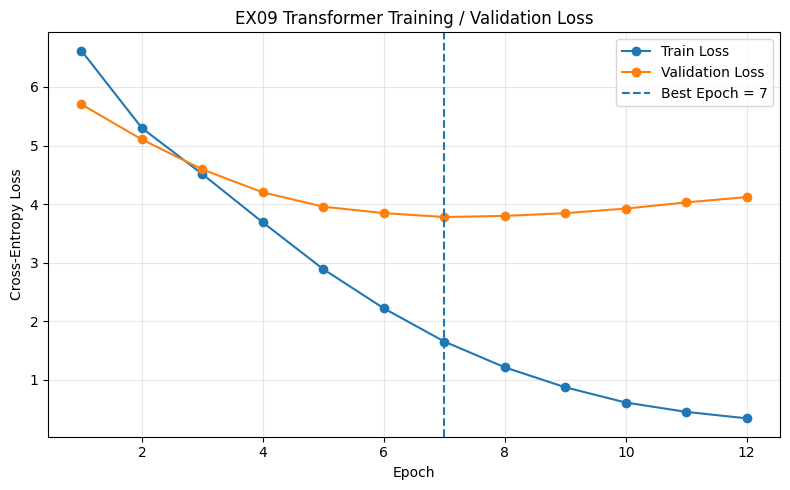

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/ex09_loss_curve.png


In [ ]:
# ============================================================
# Step 4-14. Training Curves
# ============================================================

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

best_epoch = int(np.argmin(history["val_loss"])) + 1
best_val_loss_from_history = history["val_loss"][best_epoch - 1]

print(
    f"Best epoch from history: {best_epoch} "
    f"(Val Loss={best_val_loss_from_history:.4f})"
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("EX09 Transformer Training / Validation Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_PLOT_PATH = (
    OUTPUT_DIR /
    "ex09_loss_curve.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_PLOT_PATH)

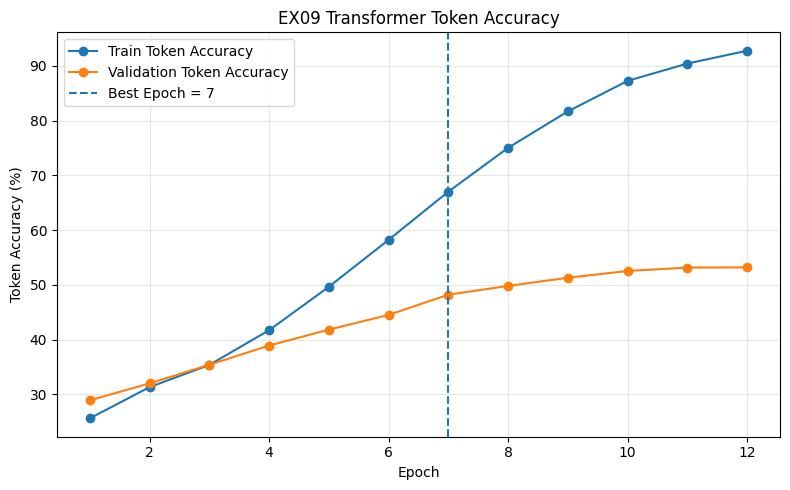

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/ex09_accuracy_curve.png


In [ ]:
# 정확도
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [
        x * 100
        for x in history["train_acc"]
    ],
    marker="o",
    label="Train Token Accuracy"
)

plt.plot(
    epochs,
    [
        x * 100
        for x in history["val_acc"]
    ],
    marker="o",
    label="Validation Token Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Token Accuracy (%)")
plt.title("EX09 Transformer Token Accuracy")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACC_PLOT_PATH = (
    OUTPUT_DIR /
    "ex09_accuracy_curve.png"
)

plt.savefig(
    ACC_PLOT_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ACC_PLOT_PATH)

## 학습 결과 분석

Transformer를 총 12 epoch 학습한 결과, Train Loss는 Epoch 1의 `6.6197`에서 Epoch 12의 `0.3403`까지 지속적으로 감소했다. Validation Loss는 `5.7033`에서 감소하여 **Epoch 7에서 최저값 `3.7787`**을 기록한 뒤 다시 증가했다.

Train Token Accuracy는 `25.60% → 92.79%`로 계속 상승한 반면, Validation Token Accuracy는 후반부 약 `53%` 수준에서 증가 폭이 둔화되었다. 따라서 Epoch 8 이후에는 Train 데이터 적합도는 계속 높아지지만 Validation 일반화 성능은 더 이상 개선되지 않는 **과적합 양상**이 나타난 것으로 판단했다.

이에 따라 최종 추론 모델은 마지막 Epoch가 아니라 **Validation Loss가 가장 낮았던 Epoch 7 checkpoint**를 선택했다.

> Token Accuracy는 Teacher Forcing 상태에서 다음 SentencePiece 토큰을 맞힌 비율이며, 완성된 챗봇 답변의 의미적 품질과 동일한 지표는 아니다. 최종 품질은 Step 5의 autoregressive generation 결과를 별도로 확인한다.


## Step 5. 모델 평가하기

Validation Loss가 가장 낮았던 checkpoint를 불러온 뒤, Teacher Forcing 없이 `BOS`에서 시작해 한 토큰씩 생성하는 autoregressive greedy decoding으로 실제 한국어 응답을 평가한다.


In [ ]:
# Validation Loss 기준 best checkpoint 불러오기

# ============================================================
# Step 5-1. Load Best Checkpoint
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

print("Best checkpoint epoch   :", checkpoint["epoch"])
print("Best validation loss    :", checkpoint["val_loss"])
print("Best checkpoint path    :", BEST_MODEL_PATH)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded.")

Best checkpoint epoch   : 7
Best validation loss    : 3.7787411714854993
Best checkpoint path    : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/ex09_transformer_best.pt
Best model loaded.


In [ ]:
# ============================================================
# Step 5-2. Autoregressive Greedy Decoding
# ============================================================

def generate_response(
    question,
    model,
    max_len=MAX_LEN
):
    model.eval()

    # ----------------------------------------
    # 1. 사용자 질문 전처리
    # ----------------------------------------

    clean_question = preprocess_sentence(
        question
    )

    # Encoder input
    src_ids = encode_and_pad(
        clean_question,
        max_len=max_len
    )

    src_tensor = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=DEVICE
    )


    # ----------------------------------------
    # 2. Decoder는 BOS 하나로 시작
    # ----------------------------------------

    generated = torch.tensor(
        [[BOS_ID]],
        dtype=torch.long,
        device=DEVICE
    )


    # ----------------------------------------
    # 3. Autoregressive Generation
    # ----------------------------------------

    with torch.no_grad():

        for _ in range(max_len - 1):

            logits, _ = model(
                src_tensor,
                generated
            )

            # 마지막 위치의 vocab logits
            next_token_logits = (
                logits[:, -1, :]
            )

            # Greedy decoding
            next_token = (
                next_token_logits.argmax(
                    dim=-1,
                    keepdim=True
                )
            )

            generated = torch.cat(
                [
                    generated,
                    next_token
                ],
                dim=1
            )

            # EOS이면 종료
            if next_token.item() == EOS_ID:
                break


    generated_ids = (
        generated[0]
        .tolist()
    )


    # BOS/EOS/PAD 제거
    output_ids = [
        token_id
        for token_id in generated_ids
        if token_id not in {
            BOS_ID,
            EOS_ID,
            PAD_ID
        }
    ]


    response = sp.decode(
        output_ids
    )


    return {
        "question":
            question,

        "clean_question":
            clean_question,

        "generated_ids":
            generated_ids,

        "response":
            response
    }

### 5-3. 자유 입력에 대한 생성 예시

아래 예시는 학습/Validation 표에서 직접 가져온 정답 비교가 아니라, 임의의 한국어 질문을 넣어 모델이 독립적으로 문장을 생성하는지 확인하는 qualitative test다. Greedy decoding을 사용하므로 매 입력에 대해 가장 높은 logit의 토큰을 순차적으로 선택한다.


In [ ]:
test_questions = [
    "공부 진짜 어렵네",
    "그럼에도 숙제 다 했다",
    "여행 원 없이 다녀왔다",
    "친구들이랑 놀러가고 싶다",
    "좋아하는 사람 나는 있는데 너는?",
    "시험 볼 일을 만들지 말자",
]

for question in test_questions:

    result = generate_response(
        question,
        model
    )

    print("=" * 70)
    print(
        "Q:",
        result["question"]
    )

    print(
        "A:",
        result["response"]
    )

Q: 공부 진짜 어렵네
A: 공부는 언제나 좋죠 .
Q: 그럼에도 숙제 다 했다
A: 많이 피곤한가봐요 .
Q: 여행 원 없이 다녀왔다
A: 잘 이겨내고 있는 거죠 .
Q: 친구들이랑 놀러가고 싶다
A: 여행은 언제나 좋죠 .
Q: 좋아하는 사람 나는 있는데 너는?
A: 사람 마다 다를 거예요 .
Q: 시험 볼 일을 만들지 말자
A: 나중에 도움이 될 거예요 .


In [ ]:
# ============================================================
# Step 5-4. Validation Qualitative Evaluation
# ============================================================

VAL_SAMPLE_COUNT = 12

val_samples = (
    val_df
    .sample(
        n=VAL_SAMPLE_COUNT,
        random_state=SEED
    )
    .reset_index(drop=True)
)

evaluation_rows = []

for _, row in val_samples.iterrows():

    question = row["Q"]
    ground_truth = row["A"]

    result = generate_response(
        question,
        model
    )

    evaluation_rows.append({
        "Question": question,
        "Ground Truth": ground_truth,
        "Generated": result["response"]
    })


evaluation_df = pd.DataFrame(
    evaluation_rows
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(evaluation_df)

,Question,Ground Truth,Generated
0,먹을 게 일도 없어,장 보러 갈 타이밍이네요.,장 보러 가봅시다 .
1,패디나 할까,기분전환을 해보세요.,저도 배워보고 싶어요 .
2,언젠가는 나를 좋아해 주는 사람 있겠지?,저도 좋아해요.,자신의 독특함을 믿으세요 .
3,아메리카노 한 잔,마시면 좋죠.,저랑 한 잔 해요 .
4,중2 히스테리 알아?,힘들 때네요.,흥미를 가져보세요 .
5,좋아하는 남자애한테 발렌타인데이 때 초콜릿 줄까?,주면 좋아할 거예요.,사람마다 다르겠지만 사귀고 난 후가 좋겠어요 .
6,머리는 아는데 가슴은 모르네,머리랑 가슴이 가끔 따로 놀죠.,지금은 괜찮냐고 물어보세요 .
7,나만의 시간이 필요해,자신과 대화하는 시간이 필요하죠.,시간은 상대적이죠 .
8,그의 환심을 살 수 있을까?,노력하는 데에 따라 다르겠죠.,인내할 수 있는 사람이라면 무엇이든 손에 넣을 수 있을 거예요 .
9,폰 베터리가 벌써 없어,베터리만 바꿔보세요.,이젠 그녀를 놓아주세요 .


In [ ]:
# 얼마나 외웠니?

# ============================================================
# Step 5-5. Train vs Validation Generation Comparison
# ============================================================

def evaluate_samples(
    dataframe,
    split_name,
    n=6
):
    samples = (
        dataframe
        .sample(
            n=n,
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    rows = []

    for _, row in samples.iterrows():

        result = generate_response(
            row["Q"],
            model
        )

        rows.append({
            "Split": split_name,
            "Question": row["Q"],
            "Ground Truth": row["A"],
            "Generated": result["response"]
        })

    return rows


comparison_rows = []

comparison_rows += evaluate_samples(
    train_df,
    "TRAIN",
    n=6
)

comparison_rows += evaluate_samples(
    val_df,
    "VALIDATION",
    n=6
)


comparison_df = pd.DataFrame(
    comparison_rows
)

display(comparison_df)

,Split,Question,Ground Truth,Generated
0,TRAIN,외모는 내 취향인데 좋아하는 걸까?,자기 취향이더라도 마음이 꼭 움직이는 건 아니에요.,사람마다 다르겠지만 사귀고 난 후가 좋겠어요 .
1,TRAIN,그녀의 결혼 너무 가슴이 아프네,이젠 그녀를 놓아주세요.,그래도 배울 점이 하나라도 있을 거예요 .
2,TRAIN,친구들은 다 예쁘게 하고 왔어,당신도 예뻐요.,당신도 예뻐요 .
3,TRAIN,이젠 어쩌죠.,생각을 정리해 보세요.,많이 지쳤나봐요 .
4,TRAIN,남자 보통 어디서 만나,소개팅 시켜달라고 말해보세요.,소개팅 시켜달라고 말해보세요 .
5,TRAIN,멍 때리기,잠깐씩 멍때리는것도 정신건강에 좋아요.,잠깐씩 멍때리는것도 정신건강에 좋아요 .
6,VALIDATION,먹을 게 일도 없어,장 보러 갈 타이밍이네요.,장 보러 가봅시다 .
7,VALIDATION,패디나 할까,기분전환을 해보세요.,저도 배워보고 싶어요 .
8,VALIDATION,언젠가는 나를 좋아해 주는 사람 있겠지?,저도 좋아해요.,자신의 독특함을 믿으세요 .
9,VALIDATION,아메리카노 한 잔,마시면 좋죠.,저랑 한 잔 해요 .


### 5-6. 생성 결과 해석

Best checkpoint(Epoch 7)는 **한국어 문장 형식과 대화형 응답 패턴을 학습했지만, 모든 입력에서 세부 의미를 안정적으로 연결하지는 못했다.**

Validation 예시에서는 다음과 같이 Ground Truth와 표현은 다르지만 맥락에 맞는 새로운 응답이 확인되었다.

```text
Q: 먹을 게 일도 없어
GT: 장 보러 갈 타이밍이네요.
Generated: 장 보러 가봅시다.

Q: 아메리카노 한 잔
GT: 마시면 좋죠.
Generated: 저랑 한 잔 해요.
```

반면 `"폰 베터리가 벌써 없어" → "이젠 그녀를 놓아주세요."`처럼 질문과 의미가 맞지 않는 응답과, 일부 문법적으로 어색한 생성도 나타났다.

Train/Validation 비교에서는 Train 질문 일부에 대해 Ground Truth를 거의 그대로 재현한 반면, Validation에서는 응답 품질의 편차가 더 컸다. 이는 학습 곡선에서 관찰한 **Epoch 7 이후의 과적합 및 제한된 일반화 능력**과 일관된다.

따라서 본 모델은 제한된 약 1만 개 Q-A 데이터로 처음부터 학습한 scratch Transformer로서 **기본적인 한국어 생성과 일부 문맥 대응에는 성공했지만, 정밀한 의미 일반화에는 한계가 있는 모델**로 평가한다.


## 프로젝트 회고

이번 프로젝트에서 가장 크게 연결된 부분은 Transformer의 개별 개념이 실제 학습 파이프라인 안에서 어떤 역할을 하는지 확인한 점이다. SentencePiece로 문자열을 token ID로 바꾸고, Embedding과 Positional Encoding을 거친 표현이 Self-Attention과 Cross-Attention을 통과한 뒤 vocabulary logits이 되는 전체 흐름을 실제 tensor shape로 확인했다.

특히 Teacher Forcing과 Causal Mask가 서로 다른 역할을 한다는 점이 명확해졌다. Teacher Forcing은 Decoder에 **과거의 정답 토큰**을 제공하고, Causal Mask는 병렬 계산 중에도 **미래의 정답 토큰을 보지 못하게 차단**한다. 또한 Padding Mask는 Attention에서 PAD를 무시하게 하고, `ignore_index=PAD_ID`는 Loss에서 PAD 정답을 제외한다는 차이도 실제 코드로 연결했다.

학습 측면에서는 Loss가 감소하는 것만으로 충분하지 않고 Train/Validation의 차이를 함께 봐야 한다는 점을 확인했다. Epoch 7 이후 Train 성능은 계속 좋아졌지만 Validation Loss는 다시 증가했고, 실제 생성 비교에서도 Train 정답 재현과 Validation 품질 편차가 함께 나타났다. 따라서 마지막 Epoch가 아니라 Validation Loss가 가장 낮은 checkpoint를 선택했다.

한계는 약 1만 개의 짧은 Q-A만으로 약 879만 개 파라미터의 Transformer를 처음부터 학습했기 때문에 문장 형식과 자주 등장하는 대화 패턴은 익혔지만 세밀한 의미 일반화는 부족했다.
